In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
ad_df = pd.read_csv("ad_spend_data.csv")

web_df = pd.read_csv("web_analytics_log.csv")

crm_df = pd.read_csv("crm_conversion_data.csv")

In [5]:
web_df["timestamp"] = pd.to_datetime(
    web_df["timestamp"]
)

crm_df["conversion_date"] = pd.to_datetime(
    crm_df["conversion_date"]
)

In [6]:
first_touch = (
    web_df
    .sort_values("timestamp")
    .groupby("user_id")
    .first()
    .reset_index()
)

In [7]:
first_touch.head()

,user_id,session_id,timestamp,channel,utm_source,utm_medium,utm_campaign,page_visited,session_duration_sec,device
0,USR_00001,SES_323717,2024-03-07 21:21:00,Meta_Facebook,facebook,cpc,FB_Awareness,/pricing,399,desktop
1,USR_00002,SES_396567,2024-03-25 00:58:00,Meta_Facebook,facebook,cpc,FB_Retargeting,/blog,871,desktop
2,USR_00003,SES_338703,2024-03-06 08:26:00,Google_Search,google,cpc,GSearch_Generic,/about,491,tablet
3,USR_00004,SES_415989,2024-01-07 19:05:00,Meta_Facebook,facebook,cpc,FB_Awareness,/pricing,813,desktop
4,USR_00005,SES_404771,2024-01-24 21:04:00,Email,email,email,Email_Retention,/pricing,130,mobile


In [8]:
first_touch_channel = (
    first_touch["channel"]
    .value_counts()
)

first_touch_channel

channel
Google_Search    557
Meta_Facebook    508
TikTok           328
Email            231
Organic          212
LinkedIn         164
Name: count, dtype: int64

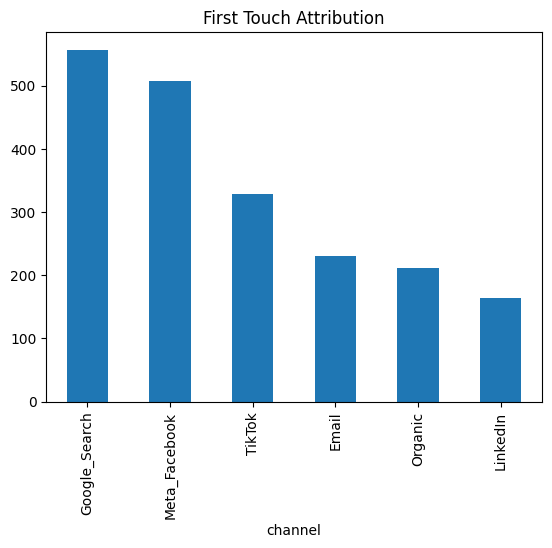

In [9]:
first_touch_channel.plot(
    kind="bar"
)

plt.title(
    "First Touch Attribution"
)

plt.show()

In [10]:
last_touch = (
    web_df
    .sort_values("timestamp")
    .groupby("user_id")
    .last()
    .reset_index()
)

In [11]:
last_touch_channel = (
    last_touch["channel"]
    .value_counts()
)

last_touch_channel

channel
Google_Search    596
Meta_Facebook    477
TikTok           309
Email            209
LinkedIn         206
Organic          203
Name: count, dtype: int64

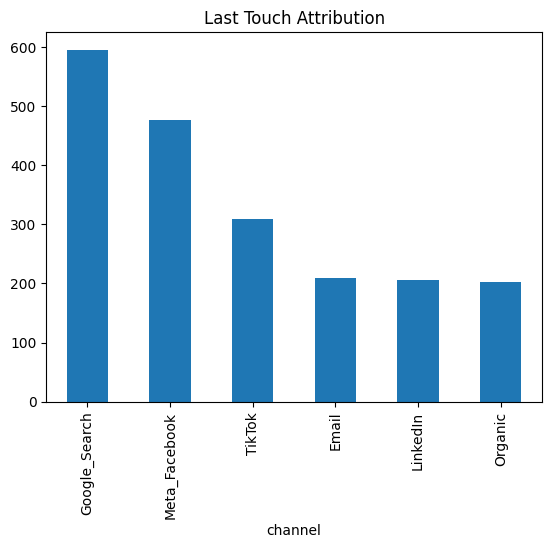

In [12]:
last_touch_channel.plot(
    kind="bar"
)

plt.title(
    "Last Touch Attribution"
)

plt.show()

In [13]:
revenue_channel = (
    crm_df
    .groupby("last_touch_channel")
    ["revenue_usd"]
    .sum()
    .sort_values(
        ascending=False
    )
)

revenue_channel

last_touch_channel
Google_Search    43583.44
Meta_Facebook    41564.63
TikTok           24587.92
LinkedIn         16716.83
Organic          16696.59
Email            14329.86
Name: revenue_usd, dtype: float64

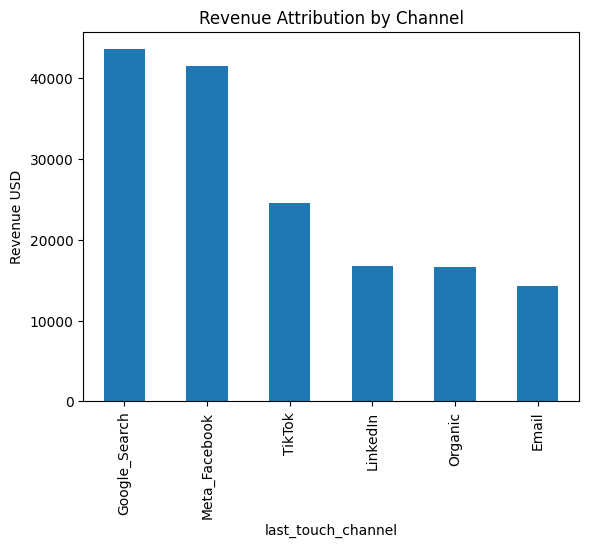

In [14]:
revenue_channel.plot(
    kind="bar"
)

plt.title(
    "Revenue Attribution by Channel"
)

plt.ylabel(
    "Revenue USD"
)

plt.show()

In [15]:
channel_spend = (
    ad_df
    .groupby("channel")
    ["amount_spent_usd"]
    .sum()
)

In [16]:
channel_spend

channel
Email             45909.35
Google_Search    483302.68
LinkedIn         252163.24
Meta_Facebook    304221.15
Organic               0.00
TikTok           150570.08
Name: amount_spent_usd, dtype: float64

In [17]:
roas_df = pd.DataFrame(
    channel_spend
)

roas_df.columns = [
    "spend"
]

In [18]:
roas_df["revenue"] = (
    revenue_channel
)

In [19]:
roas_df = roas_df.fillna(0)

In [20]:
roas_df["roas"] = (
    roas_df["revenue"]
    /
    roas_df["spend"]
)

In [21]:
roas_df.sort_values(
    "roas",
    ascending=False
)

,spend,revenue,roas
channel,,,
Organic,0.00,16696.59,inf
Email,45909.35,14329.86,0.312134
TikTok,150570.08,24587.92,0.163299
Meta_Facebook,304221.15,41564.63,0.136626
Google_Search,483302.68,43583.44,0.090178
LinkedIn,252163.24,16716.83,0.066294


C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


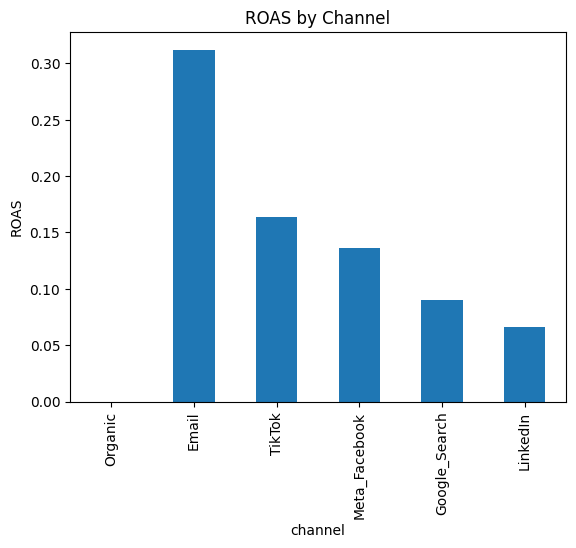

In [22]:
roas_df["roas"].sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title(
    "ROAS by Channel"
)

plt.ylabel(
    "ROAS"
)

plt.show()

In [23]:
campaign_revenue = (
    crm_df
    .groupby(
        "last_touch_campaign"
    )
    ["revenue_usd"]
    .sum()
    .sort_values(
        ascending=False
    )
)

campaign_revenue.head(10)

last_touch_campaign
FB_Awareness          17140.34
GSearch_Generic       14732.03
TikTok_Promo          14633.88
GSearch_Brand         14321.60
FB_Lookalike          13815.57
GSearch_Competitor    12988.80
Organic_SEO            8958.13
FB_Retargeting         8655.36
LinkedIn_B2B           8569.79
TikTok_Video1          8347.51
Name: revenue_usd, dtype: float64

In [24]:
attribution_summary = pd.DataFrame({
    "Channel":
        roas_df.index,
    "Spend":
        roas_df["spend"],
    "Revenue":
        roas_df["revenue"],
    "ROAS":
        roas_df["roas"]
})

attribution_summary

,Channel,Spend,Revenue,ROAS
channel,,,,
Email,Email,45909.35,14329.86,0.312134
Google_Search,Google_Search,483302.68,43583.44,0.090178
LinkedIn,LinkedIn,252163.24,16716.83,0.066294
Meta_Facebook,Meta_Facebook,304221.15,41564.63,0.136626
Organic,Organic,0.00,16696.59,inf
TikTok,TikTok,150570.08,24587.92,0.163299
